## 0. Importing PyTorch and setting up device-agnostic code

In [95]:
import torch
from torch import nn

torch.__version__

'2.5.1+cu124'

In [96]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 1. Get data

In [97]:
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)

data/pizza_steak_sushi directory exists.


## 2. Becoming one with the Data (Data exploration)

In [98]:
import os
def walk_through_dir(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

In [99]:
walk_through_dir(image_path)

There are 2 directories and 0 images in data/pizza_steak_sushi
There are 3 directories and 0 images in data/pizza_steak_sushi/train
There are 0 directories and 78 images in data/pizza_steak_sushi/train/pizza
There are 0 directories and 75 images in data/pizza_steak_sushi/train/steak
There are 0 directories and 72 images in data/pizza_steak_sushi/train/sushi
There are 3 directories and 0 images in data/pizza_steak_sushi/test
There are 0 directories and 25 images in data/pizza_steak_sushi/test/pizza
There are 0 directories and 19 images in data/pizza_steak_sushi/test/steak
There are 0 directories and 31 images in data/pizza_steak_sushi/test/sushi


In [100]:
# Setup training and testing path
train_dir = image_path/"train"
test_dir = image_path/"test"

In [101]:
train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### Visualizing an image

1. Get the image paths
2. Pick a random image path using Python's random.choice()
3. Get the image class name using `pathlib.Path.parent.stem`
4. Open image using PIL
5. Show image's metadata

data/pizza_steak_sushi/train/pizza/68684.jpg
pizza
Random image path: data/pizza_steak_sushi/train/pizza/68684.jpg
Image class: pizza
Image height: 384
Image width: 512


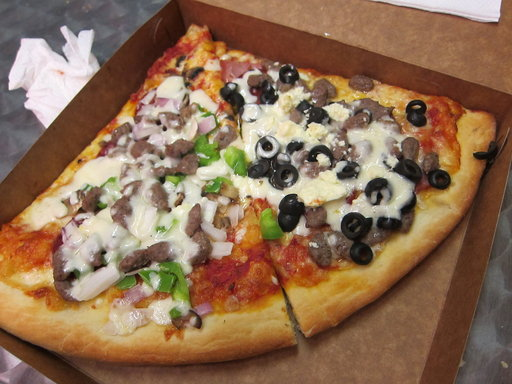

In [102]:
import random
from PIL import Image

# Set seed
random.seed(42)

# Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

# image_path_list

# Pick random image path
random_image_path = random.choice(image_path_list)
print(random_image_path)

# Get image class
image_class = random_image_path.parent.stem
print(image_class)

# Open the image
img = Image.open(random_image_path)

# Render the image
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

(-0.5, 511.5, 383.5, -0.5)

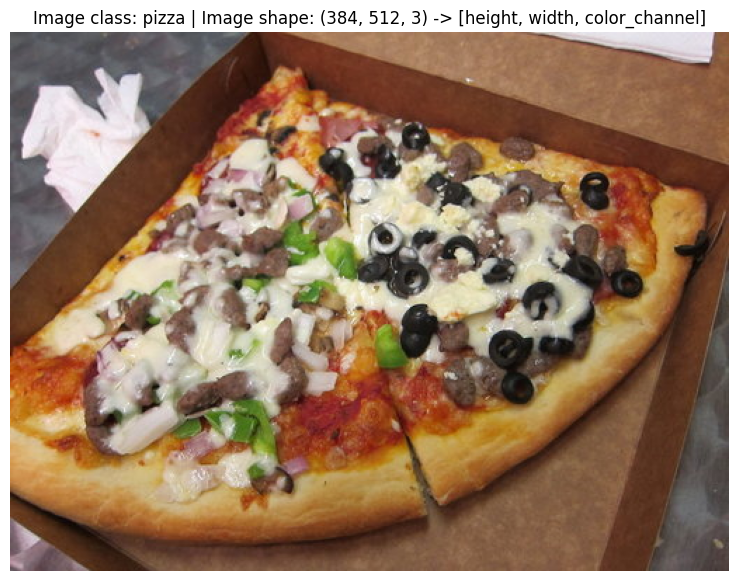

In [103]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize= (10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channel]")
plt.axis(False)

## 3. Transforming data

1. Turn the target data into tensors
2. Turn them into `torch.utils.data.Dataset` and then subsequently to `torch.utils.data.DataLoader` format

In [104]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 3.1 Transforming data with `torchvision.transforms`

In [105]:
# Wrtie a transform for image
data_transform = transforms.Compose([
    # Resize the images to 64x64
    transforms.Resize(size = (64, 64)),
    # Flip the image randomly on the horizontal
    transforms.RandomHorizontalFlip(p = 0.5),
    # Turn image into a torch Tensor
    transforms.ToTensor()
])

In [106]:
data_transform(img).shape

torch.Size([3, 64, 64])

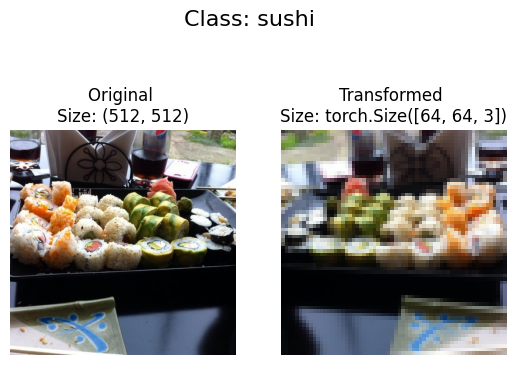

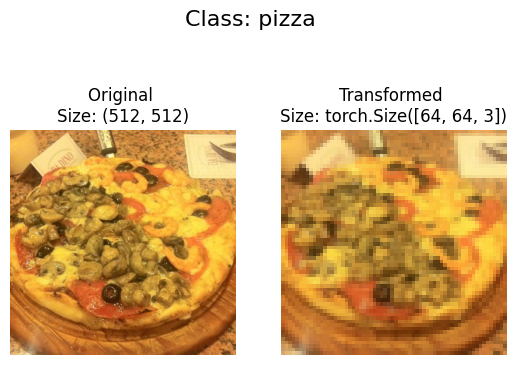

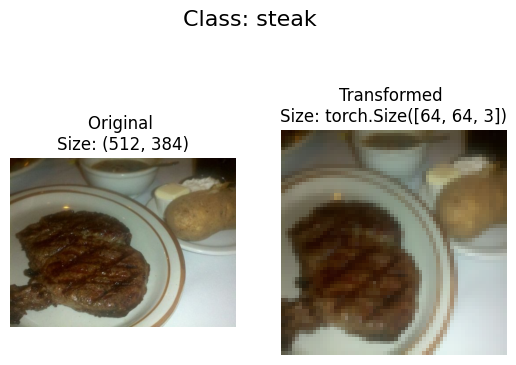

In [107]:
def plot_transformed_images(image_paths: list,
                            transform, n =3, seed = None):
  """
  Selects random images from the list of image paths. Then plots the original image and the transformed one
  """
  random.seed(seed)
  random_image_paths = random.sample(image_paths, k=n)
  for image_path in random_image_paths:
      with Image.open(image_path) as f:
          fig, ax = plt.subplots(1, 2)
          ax[0].imshow(f)
          ax[0].set_title(f"Original \nSize: {f.size}")
          ax[0].axis("off")

          # Transform and plot image
          # Note: permute() will change shape of image to suit matplotlib
          # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
          transformed_image = transform(f).permute(1, 2, 0)
          ax[1].imshow(transformed_image)
          ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
          ax[1].axis("off")

          fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path_list,
                        transform=data_transform,
                        n=3)

## 4. Option 1: Loading image data using `ImageFolder`

In [108]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root = train_dir,
                                  transform= data_transform, # transformation to be implemented for the images
                                  target_transform= None) # transformation to be implemented for the labels
test_data = datasets.ImageFolder(root = test_dir,
                                  transform= data_transform) # transformation to be implemented for the images

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [109]:
# Get class names as list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [110]:
# Get class names as dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [111]:
# Check the length of the dataset
len(train_data), len(test_data)

(225, 75)

In [112]:
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [113]:
train_data.targets[0]

0

In [114]:
# Index on the tain_data dataset to get a single image and label
img, label = train_data[0][0], train_data[0][1]

print(f"Image tensor :{img}")
print(f"Image shape :{img.shape}")
print(f"Image datatype :{img.dtype}")
print(f"Image label :{label}")
print(f"Label data type: {type(label)}")

Image tensor :tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.01

In [115]:
class_names[label]

'pizza'

In [116]:
# Rearrange the order dimensions
img_permute = img.permute(1, 2, 0)
print(f"Image shape before permute: {img.shape}")
print(f"Image shape after permute: {img_permute.shape}")

Image shape before permute: torch.Size([3, 64, 64])
Image shape after permute: torch.Size([64, 64, 3])


### Turn loaded images into `DataLoader`'s

In [117]:
import os
os.cpu_count() # number of CPUs available for getting the work done

2

In [118]:
# Turn train and test datasets into DataLoaders
from torch.utils.data import DataLoader
BATCH_SIZE = 1
train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              num_workers= os.cpu_count(),
                              shuffle  =True)

test_dataloader = DataLoader(dataset= test_data,
                             batch_size= 1,
                             num_workers= os.cpu_count(),
                             shuffle= False)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7b4d059c7bd0>,
 <torch.utils.data.dataloader.DataLoader at 0x7b4d2b354d50>)

In [119]:
len(train_dataloader), len(test_dataloader)

(225, 75)

In [120]:
img, label = next(iter(train_dataloader))

# Batch size will be 1, as for now
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


## 5. Option 2: Loading image data with custom `Dataset`

Implementing the same functionality as above, but now with our own code.

In [121]:
import os
import pathlib
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

### 5.1 Creating a helper function to get class names

In [122]:
# Setup path for target directory
target_directory = train_dir
print(f"Target dir: {target_directory}")

# Get the class names
class_names_found = sorted([entry.name for entry in os.scandir(target_directory) if entry.is_dir()])
print(f"Class names found: {class_names_found}")

Target dir: data/pizza_steak_sushi/train
Class names found: ['pizza', 'steak', 'sushi']


In [123]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
  """
  Find the folders for a particular directory
  """
  classes = sorted([entry.name for entry in os.scandir(target_directory) if entry.is_dir()])
  # print(f"Class names found: {classes}")

  # Raise an error if no class names are found
  if not classes:
    raise FileNotFoundError(f"Could not find any subdirectories in {directory}")

  # Create a dictionary of index to class mapping
  class_to_idx = {class_name: i for i, class_name in enumerate(classes)}

  return classes, class_to_idx

In [124]:
classes, class_dict = find_classes(target_directory)
classes, class_dict

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Create a custom `Dataset` to replicate `ImageFolder`

1. Subclass `torch.utils.data.Dataset`
2. Init our subclass with target directory as well as a transform if there is transformation involved
3. Create several attributes:
  * path- paths of our images
  * transform - the transform we'd like to use
  * classes - a list of target classes
  * class_to_idx - a dict of target classes mapped to integer labels
4. Create a function to `load_images()` which will essentially open the image
5. Overwrite the `__len()__` method to return the length of our dataset
6. Overwrite the `__getitem()__` method to return a given sample when passed an index

In [125]:
# Write a custom datasets class
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):
  # 2. Initialise the custom dataset
  def __init__(self, targ_dir :str, transform = None):
    # 3. Create class attributes
    # Get all of the image paths
    self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
    # Setup transforms
    self.transform = transform
    # Create classes and class_to_idx
    self.classes, self.class_to_idx = find_classes(targ_dir)

  # 4. Create a function to load images
  def load_image(self, index: int) ->Image.Image:
    image_path = self.paths[index]
    return Image.open(image_path)

  # 5. Overwrite the len method
  def __len__(self) ->int:
    return len(self.paths)

  # 5. Overwrite the getitem()
  def __getitem__(self, index:int) -> Tuple[torch.Tensor, int]:

    """
    Retunrns the sample of data and the target
    """
    img = self.load_image(index)
    class_name = self.paths[index].parent.name # expects path in form: data_folder/ class_name/ image.jpg
    class_idx = self.class_to_idx[class_name]

    # Transform if necessary
    if self.transform:
      return self.transform(img), class_idx
    else:
      return img, class_idx

In [126]:
# Create a transform
from torchvision.transforms import transforms
train_transforms = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor()
])


test_transforms = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.ToTensor()
])

In [127]:
# Test out ImageFolderCustom
train_data_custom = ImageFolderCustom(targ_dir= train_dir,
                                      transform= train_transforms)

test_data_custom = ImageFolderCustom(targ_dir= test_dir,
                                     transform= test_transforms)

In [128]:
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7b4d059d5210>,
 <__main__.ImageFolderCustom at 0x7b4d059929d0>)

In [129]:
len(train_data_custom), len(train_data)

(225, 225)

In [130]:
len(test_data_custom), len(test_data)

(75, 75)

In [131]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [132]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [133]:
# Check for equality between train_data and train_data_custom
print(train_data_custom.classes == train_data.classes)
print(test_data_custom.classes == test_data.classes)

True
True


### 5.3 Create a function to display random images

In [134]:
# 1. Create the function to take in the dataset
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str] = None,
                          n: int =10,
                          display_shape: bool =True,
                          seed: int = None):
  # 2. Adjust display if n is too high
  if n> 10:
    n = 10
    display_shape = False

  # 3. Set seed
  if seed:
    random.seed(seed)

  # 4. Get random sample indexes
  random_samples_idx = random.sample(range(len(dataset)), k =n)

  # 5. Setup plots
  plt.figure(figsize = (16, 8))

  # 6. Loop through random indexes and plot them with matplotlib
  for i, targ_sample in enumerate(random_samples_idx):
    targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

    # 7. Adjust tensor dimensions for plotting
    targ_image_adjust = targ_image.permute(1, 2, 0) # [c, h, w] -> [h, w, c]

    # Plot adjusted samples
    plt.subplot(1, n, i+1)
    plt.imshow(targ_image_adjust)
    plt.axis(False)
    if classes:
      title = f"{classes[targ_label]}"
      if display_shape:
        title = title + f"\nshape: {targ_image_adjust.shape}"
      plt.title(title)

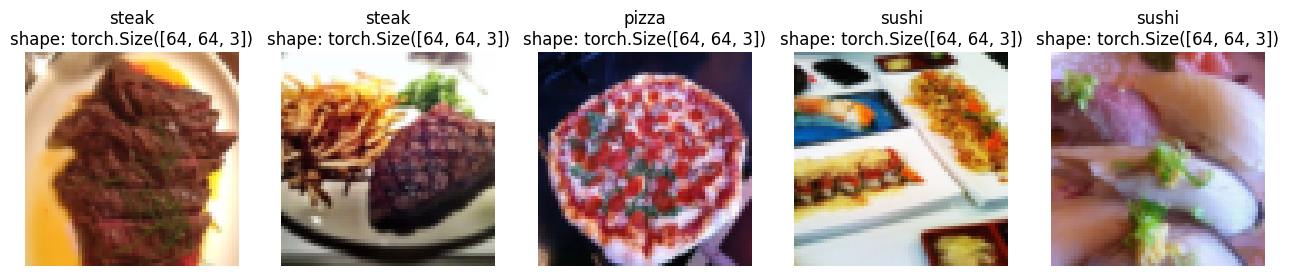

In [135]:
# Display random images from the ImageFolder created Dataset
display_random_images(dataset= train_data,
                      n =5,
                      classes= class_names,
                      seed = None)

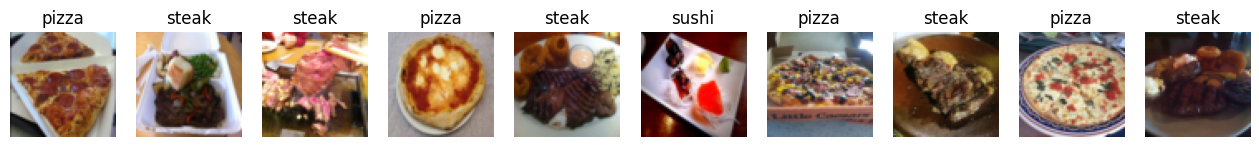

In [136]:
# Display random iamges from ImageFolderCustom Dataset
display_random_images(dataset= train_data_custom,
                      n =20,
                      classes= class_names,
                      seed = None)

### 5.4 Turn custom loaded images into `DataLoaders`

In [137]:
from torch.utils.data import DataLoader
BATCH_SIZE= 32
NUM_WORKERS = os.cpu_count()
train_dataloader_custom = DataLoader(dataset= train_data_custom,
                                     batch_size = BATCH_SIZE,
                                     num_workers= NUM_WORKERS,
                                     shuffle = True)

test_dataloader_custom =  DataLoader(dataset= test_data_custom,
                                     batch_size= BATCH_SIZE,
                                     num_workers= NUM_WORKERS,
                                     shuffle= False)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7b4d006d8210>,
 <torch.utils.data.dataloader.DataLoader at 0x7b4d008b00d0>)

In [138]:
# Get image and label from custom data loader
img_custom, label_custom = next(iter(train_dataloader_custom))

# print out shapes
img_custom.shape, label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

## 6. Other forms of transforms (Data Augmentation)

In [139]:
import torchvision
print(torchvision.__version__)  # Check version
import torchvision.transforms as transforms

0.20.1+cu124


In [140]:
# We would be looking into Trivial Augment. This augments the image using random and diverse transformations
train_transform = transforms.Compose([
    transforms.Resize(size = (224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins = 31), # the num_magnitude_bins is like a representation of how much of intense of augmentation do we want? value differs between 0-31
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(size = (224, 224)),
    transforms.ToTensor()
])

In [141]:
image_path

PosixPath('data/pizza_steak_sushi')

In [142]:
# Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/train/pizza/2190018.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1089334.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/2291093.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/3281494.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/3699992.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/3530210.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/12301.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/2924941.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/667309.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1285298.jpg')]

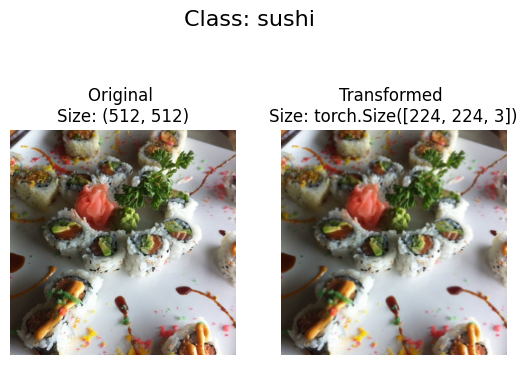

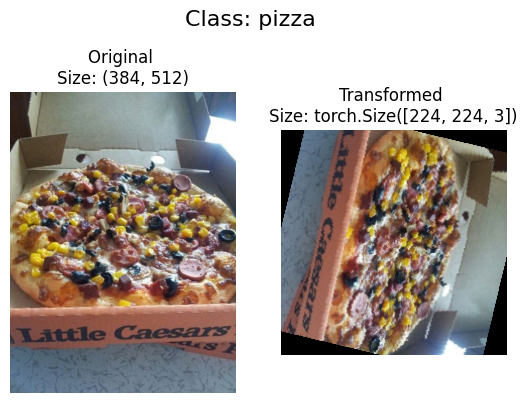

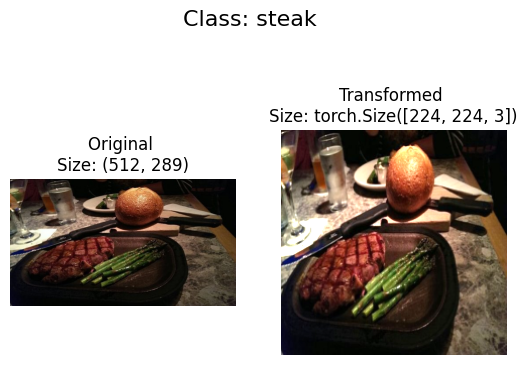

In [143]:
# Plot random images
plot_transformed_images(image_paths= image_path_list,
                        transform = train_transform)

## 7. Model 0: TinyVGG, from CNN explainer without Data Augmentation

### 7.1 Creating transforms and laoding data from model 0

In [144]:
# Create simple transforms
simple_transform = transforms.Compose([
    transforms.Resize(size= (64, 64)),
    transforms.ToTensor()
])

In [145]:
# 1. Laod and transform the data
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root = train_dir,
                                         transform= simple_transform)
test_data_simple = datasets.ImageFolder(root = test_dir,
                                        transform= simple_transform)

# 2. Turn dataset to DataLoader
import os
from torch.utils.data import DataLoader

# Setup the hyperparameters
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader_simple = DataLoader(dataset= train_data_simple,
                                     batch_size= BATCH_SIZE,
                                     num_workers= NUM_WORKERS,
                                     shuffle= True)

test_dataloader_simple = DataLoader(dataset= test_data_simple,
                                    batch_size= BATCH_SIZE,
                                    num_workers= NUM_WORKERS)

In [146]:
import torch
import torch.nn as nn

class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is the same as kernel size
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is the same as kernel size
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 13 * 13,
                      out_features=output_shape)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x
        # return (self.classifier(self.conv_block_2(self.conv_block_1(x)))) # doing this improves the GPU performance by implementing operator fusion

In [147]:
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_names = ["class_1", "class_2", "class_3"]
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(class_names)).to(device)

print(model_0)

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)


### 7.3 Try a forward pass on a single image (to test the model & figure out the input for classifier block)

In [148]:
# get single image
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [149]:
# try a forward pass
model_0(image_batch.to(device))

tensor([[ 2.0795e-02, -1.9510e-03,  9.5212e-03],
        [ 1.8440e-02,  2.4668e-03,  6.6609e-03],
        [ 1.7695e-02,  1.0282e-03,  9.4975e-03],
        [ 2.4446e-02, -3.3489e-03,  9.5877e-03],
        [ 1.9939e-02,  6.9131e-04,  1.0778e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0046e-03],
        [ 2.0996e-02,  1.6415e-04,  1.2481e-02],
        [ 2.1566e-02, -1.9607e-03,  9.7175e-03],
        [ 2.4500e-02, -4.7904e-03,  8.5394e-03],
        [ 2.0239e-02, -4.7979e-04,  1.0907e-02],
        [ 2.2219e-02, -4.1816e-04,  9.8173e-03],
        [ 2.2318e-02, -2.1642e-03,  9.4428e-03],
        [ 2.1851e-02, -3.7225e-03,  8.3784e-03],
        [ 2.2881e-02, -1.7559e-03,  1.0299e-02],
        [ 2.1635e-02, -4.3995e-03,  9.4990e-03],
        [ 2.2101e-02, -4.1469e-03,  9.3904e-03],
        [ 2.1226e-02, -4.4215e-03,  1.1476e-02],
        [ 2.1698e-02, -2.7458e-03,  8.4966e-03],
        [ 1.9974e-02, -3.1665e-07,  8.4496e-03],
        [ 1.8308e-02,  1.6378e-03,  8.5491e-03],
        [ 2.0768e-02

### 7.4 Using `torchinfo` get an overview of the model we are working with

In [150]:
try:
    import torchinfo
except ImportError:
    !pip install torchinfo  # Install only if it's not available
    import torchinfo  # Import after installation

from torchinfo import summary

summary(model_0, input_size=(1, 3, 64, 64))  # This is like sending a batch of one image

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

## 7.5 Create training and testing loops

In [151]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device = device):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [152]:
# Create test step
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device = device):
    # put model in eval mode
    model.eval()

    # setup loss and accuracy metrics
    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        # loop through data batches
        for (X, y) in dataloader:  # Unpack X (images) and y (labels)
            # send data on to device
            X, y = X.to(device), y.to(device)

            # forward pass
            test_pred_logits = model(X)

            # calculate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # calculate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)  # Use model output, not test_data
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)

    # adjust to get average metrics per batch
    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
    return test_loss, test_acc

### 7.6 creatig a `train()` function which combines the `train_step()` and `test_step()`

In [153]:
from tqdm.auto import tqdm

# create a training function which takes in various model parameters + optimizer + dataloaders + loss functions
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          device = device):

  # create an empty results dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  # loop through training and testing
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model = model,
                                       dataloader= train_dataloader,
                                       loss_fn= loss_fn,
                                       optimizer= optimizer,
                                       device =device)
    test_loss, test_acc = test_step(model = model,
                                    dataloader= test_dataloader,
                                    loss_fn = loss_fn,
                                    device = device)

    # print info
    print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    # update the dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  # return filled results finally
  return results

### 7.7 Train and evaluate model 0

In [154]:
# set random seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# set number of epochs
NUM_EPOCHS = 5

# recreate isntance of TinyVGG
model_0 = TinyVGG(input_shape= 3, # no of colour channels
                  hidden_units = 10,
                  output_shape= len(train_data.classes)).to(device)

# setup loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_0.parameters(),
                          lr = 0.001)

# start the time
from timeit import default_timer as timer
start_time = timer()

model_0_results = train(model= model_0,
                        train_dataloader= train_dataloader_simple,
                        test_dataloader= test_dataloader_simple,
                        optimizer = optimizer,
                        loss_fn = loss_fn,
                        epochs = NUM_EPOCHS,
                        device = device)

end_time = timer()

model_0_time = end_time - start_time
print(f"Total training time: {model_0_time} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 1.1063 | Train Acc: 0.3047 | Test Loss: 1.0983 | Test Acc: 0.3011
Epoch: 1 | Train Loss: 1.0998 | Train Acc: 0.3281 | Test Loss: 1.0697 | Test Acc: 0.5417
Epoch: 2 | Train Loss: 1.0869 | Train Acc: 0.4883 | Test Loss: 1.0808 | Test Acc: 0.4924
Epoch: 3 | Train Loss: 1.0842 | Train Acc: 0.3984 | Test Loss: 1.0608 | Test Acc: 0.5833
Epoch: 4 | Train Loss: 1.0662 | Train Acc: 0.4141 | Test Loss: 1.0654 | Test Acc: 0.5644
Total training time: 10.984210771999983 seconds


In [155]:
model_0_results

{'train_loss': [1.106319084763527,
  1.0998057276010513,
  1.0868544578552246,
  1.0842333287000656,
  1.0662163645029068],
 'train_acc': [0.3046875, 0.328125, 0.48828125, 0.3984375, 0.4140625],
 'test_loss': [1.0983205238978069,
  1.069690187772115,
  1.0807572205861409,
  1.0608318249384563,
  1.0653960307439168],
 'test_acc': [0.30113636363636365,
  0.5416666666666666,
  0.49242424242424243,
  0.5833333333333334,
  0.5643939393939394]}

### 7.8 Plot loss curves of model_0

In [156]:
# Get model_0_results key
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [157]:
import matplotlib.pyplot as plt
from typing import Dict, List

def plot_loss_curves(results: Dict[str, List[float]]):
    # get the loss values
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    # get acc values
    acc = results["train_acc"]
    test_acc = results["test_acc"]

    # figure out the no of epochs
    epochs = range(len(results["train_loss"]))

    # setup a plot
    plt.figure(figsize=(15, 7))

    # detach the metrics and convert them to NumPy
    loss = [l.detach().cpu().numpy() if isinstance(l, torch.Tensor) else l for l in loss]
    acc = [a.detach().cpu().numpy() if isinstance(a, torch.Tensor) else a for a in acc]
    test_loss = [tl.detach().cpu().numpy() if isinstance(tl, torch.Tensor) else tl for tl in test_loss]
    test_acc = [ta.detach().cpu().numpy() if isinstance(ta, torch.Tensor) else ta for ta in test_acc]

    # plot the loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # plot the accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, label="train_acc")
    plt.plot(epochs, test_acc, label="test_acc")
    plt.xlabel("Epochs")
    plt.title("Accuracy")
    plt.legend()

    plt.show()

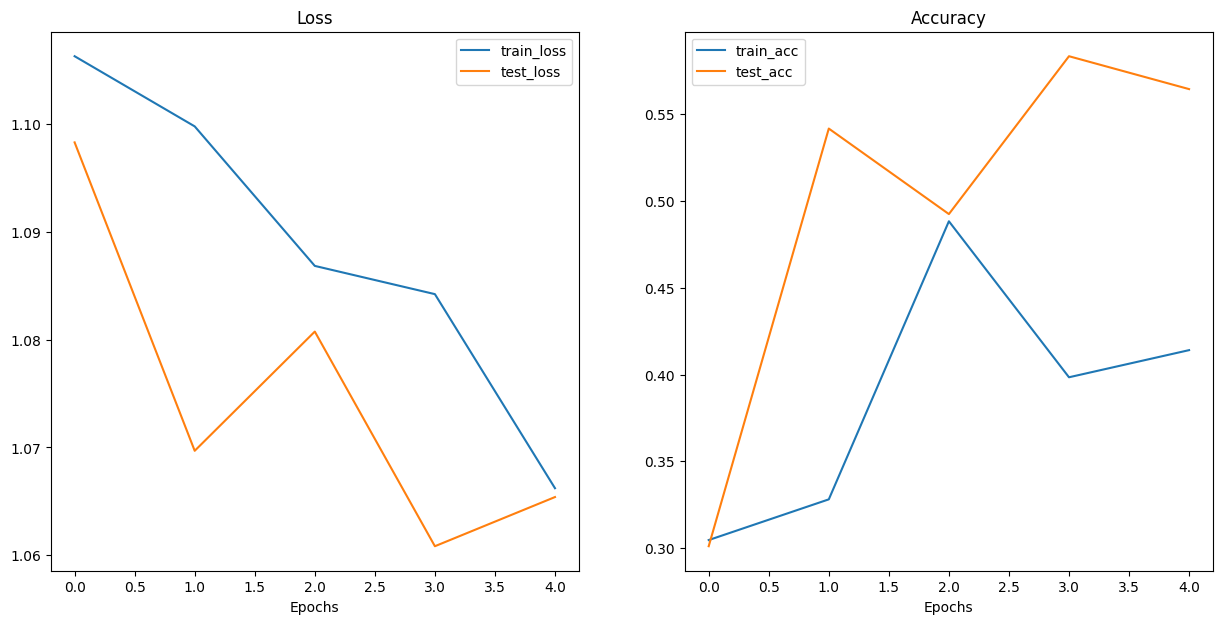

In [158]:
plot_loss_curves(model_0_results)

## 9. Model 1: TinyVGG with Data Augmentation

### 9.1 Create transform with data augmentation

In [159]:
# Create training transform
train_transform_trivial = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform_trivial = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.ToTensor()
])

### 9.2 Create train and test data and DataLoaders

In [160]:
# img folders to datasets
train_data_augmented = datasets.ImageFolder(root= train_dir,
                                            transform= train_transform_trivial)
test_data_simple = datasets.ImageFolder(root= test_dir,
                                        transform= test_transform_trivial)

In [161]:
# datasets to data loaders
import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)
train_dataloader_augmented = DataLoader(dataset= train_data_augmented,
                                        batch_size= BATCH_SIZE,
                                        num_workers= NUM_WORKERS,
                                        shuffle = True)

test_dataloader_simple = DataLoader(dataset = test_data_simple,
                                    batch_size= BATCH_SIZE,
                                    num_workers= NUM_WORKERS,
                                    shuffle = False)

### 9.3 Construct and train model 1


This time we will be using data augmentation

In [162]:
torch.manual_seed(42)
model_1 = TinyVGG(input_shape= 3,
                  hidden_units= 10,
                  output_shape= len(train_data_augmented.classes)).to(device)

model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [163]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 5

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_1
model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader_augmented,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 1.1049 | Train Acc: 0.2500 | Test Loss: 1.1019 | Test Acc: 0.2604
Epoch: 1 | Train Loss: 1.0807 | Train Acc: 0.4258 | Test Loss: 1.1261 | Test Acc: 0.2604
Epoch: 2 | Train Loss: 1.0712 | Train Acc: 0.4258 | Test Loss: 1.1593 | Test Acc: 0.2604
Epoch: 3 | Train Loss: 1.1253 | Train Acc: 0.3047 | Test Loss: 1.1581 | Test Acc: 0.2604
Epoch: 4 | Train Loss: 1.0865 | Train Acc: 0.4258 | Test Loss: 1.1554 | Test Acc: 0.3333
Total training time: 11.153 seconds


In [164]:
model_1_results

{'train_loss': [1.104914203286171,
  1.0806865319609642,
  1.0711720064282417,
  1.125308334827423,
  1.0865339040756226],
 'train_acc': [0.25, 0.42578125, 0.42578125, 0.3046875, 0.42578125],
 'test_loss': [1.1019279559453328,
  1.1260557969411213,
  1.159274657567342,
  1.1580672065416973,
  1.1554409265518188],
 'test_acc': [0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.3333333333333333]}

### 9.4 Plot loss curves of model_1

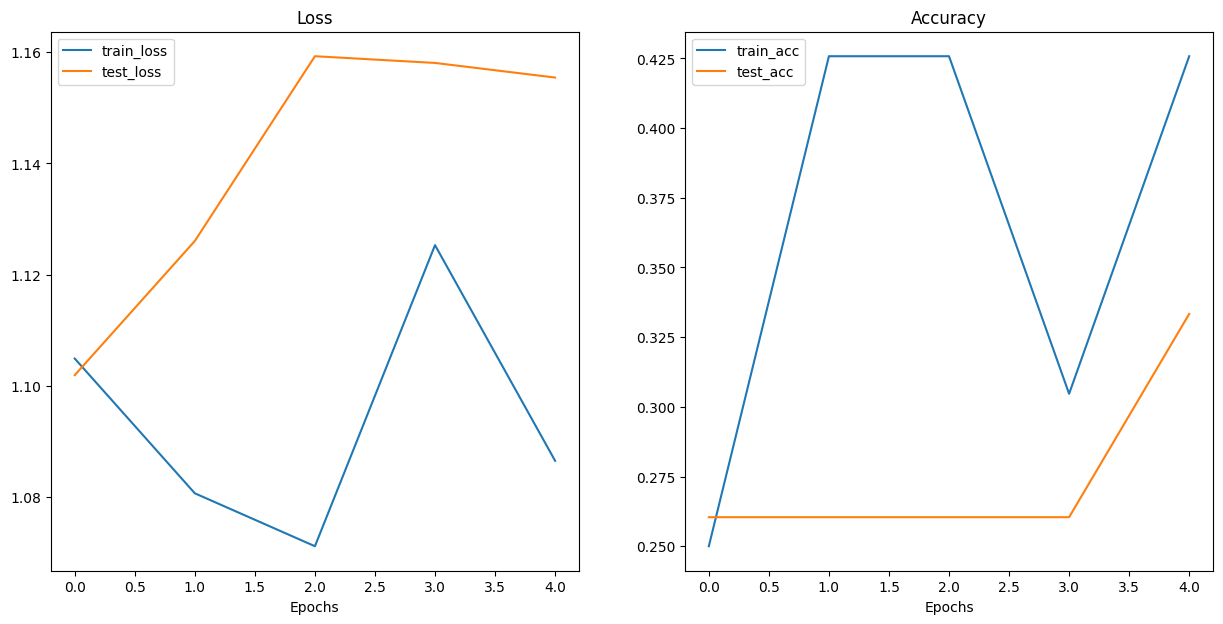

In [165]:
plot_loss_curves(model_1_results)

## 10. Compare model results

In [166]:
# hnadling the gradient based values

def tensor_to_numpy(value):
    if isinstance(value, torch.Tensor):
        # Make sure to detach AND use no_grad for safety
        with torch.no_grad():
            return value.detach().cpu().numpy()
    elif isinstance(value, (list, tuple)):
        # Handle lists and tuples of tensors
        return type(value)(tensor_to_numpy(v) for v in value)
    elif isinstance(value, dict):
        # Handle dictionaries of tensors
        return {k: tensor_to_numpy(v) for k, v in value.items()}
    return value

In [167]:
# Wrap the whole conversion in no_grad context
import pandas as pd
with torch.no_grad():
    model_0_df = pd.DataFrame({key: tensor_to_numpy(value) for key, value in model_0_results.items()})
    model_1_df = pd.DataFrame({key: tensor_to_numpy(value) for key, value in model_1_results.items()})

print(model_0_df)

   train_loss  train_acc  test_loss  test_acc
0    1.106319   0.304688   1.098321  0.301136
1    1.099806   0.328125   1.069690  0.541667
2    1.086854   0.488281   1.080757  0.492424
3    1.084233   0.398438   1.060832  0.583333
4    1.066216   0.414062   1.065396  0.564394


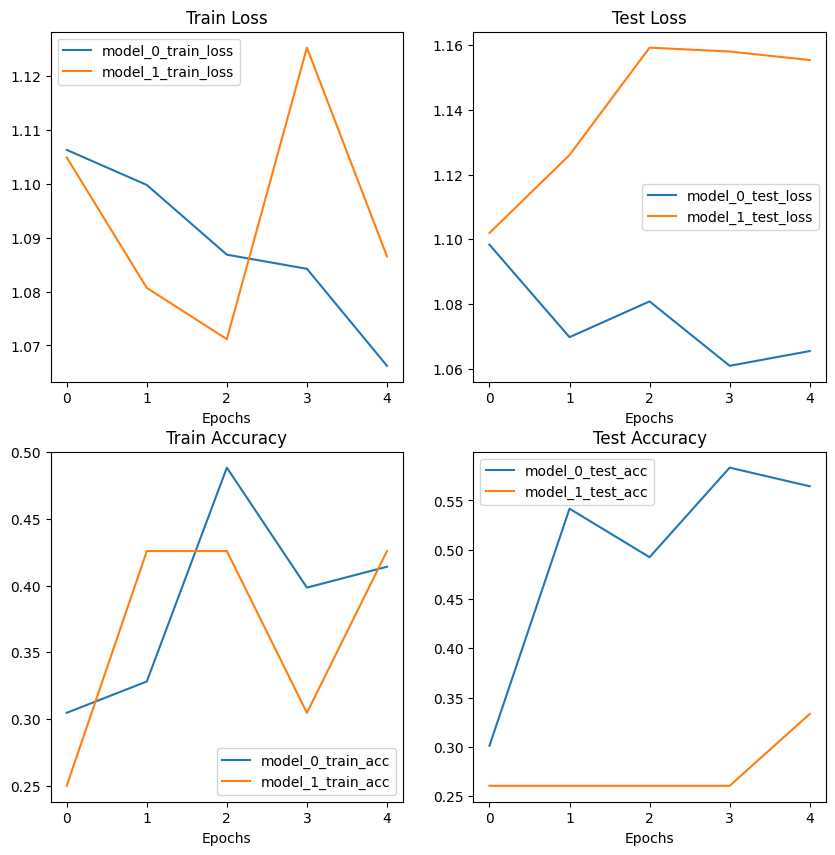

In [168]:
# Setup the plot
plt.figure(figsize=(10, 10))

# get number of epochs
epochs = range(len(model_0_df))

# plot the train loss
plt.subplot(2,2,1)
plt.plot(epochs, model_0_df["train_loss"], label="model_0_train_loss")
plt.plot(epochs, model_1_df["train_loss"], label="model_1_train_loss")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

# plot the test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label="model_0_test_loss")
plt.plot(epochs, model_1_df["test_loss"], label="model_1_test_loss")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend();

# plot the train Accuracy
plt.subplot(2,2,3)
plt.plot(epochs, model_0_df["train_acc"], label="model_0_train_acc")
plt.plot(epochs, model_1_df["train_acc"], label="model_1_train_acc")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()

# plot the test Accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_acc"], label="model_0_test_acc")
plt.plot(epochs, model_1_df["test_acc"], label="model_1_test_acc")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend();

## 11. Making a prediction on custom data

In [169]:
# Download custom image
import requests

# Setup custom image path
custom_image_path = data_path / "04-pizza-dad.jpeg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

data/04-pizza-dad.jpeg already exists, skipping download.


## 11.1 Loading in custom iamge with PyTorch

In [170]:
import torchvision

# read in custom iamge
custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))
custom_image_uint8

tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)

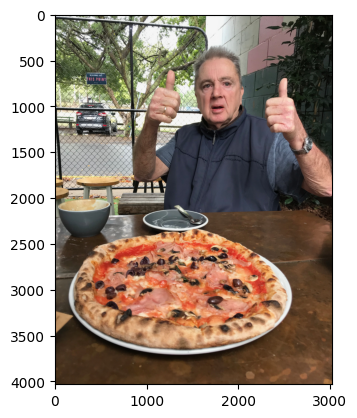

In [171]:
plt.imshow(custom_image_uint8.permute(1, 2, 0));

In [172]:
# custom image shape
custom_image_uint8.shape

torch.Size([3, 4032, 3024])

In [173]:
# custom  image datatype
custom_image_uint8.dtype

torch.uint8

our model was trained on iamge of 64 * 64 and float tensor

## 11.2 Making predictions on custom image with trained PyTorch model

In [174]:
# load in custom image and convert it to torch.float32
custom_image =  torchvision.io.read_image(str(custom_image_path)).type(torch.float32)/ 255.
custom_image

tensor([[[0.6039, 0.6784, 0.7098,  ..., 0.0824, 0.0706, 0.0549],
         [0.5725, 0.6471, 0.7098,  ..., 0.0824, 0.0706, 0.0588],
         [0.4863, 0.5725, 0.6745,  ..., 0.0706, 0.0667, 0.0588],
         ...,
         [0.2824, 0.2314, 0.1765,  ..., 0.5961, 0.5882, 0.5804],
         [0.2510, 0.2157, 0.1608,  ..., 0.5882, 0.5765, 0.5647],
         [0.2510, 0.2353, 0.1804,  ..., 0.5843, 0.5725, 0.5608]],

        [[0.6706, 0.7451, 0.7569,  ..., 0.0863, 0.0745, 0.0588],
         [0.6392, 0.7137, 0.7569,  ..., 0.0863, 0.0745, 0.0627],
         [0.5529, 0.6392, 0.7216,  ..., 0.0745, 0.0706, 0.0627],
         ...,
         [0.2157, 0.1647, 0.1098,  ..., 0.4196, 0.4078, 0.4039],
         [0.1843, 0.1490, 0.0941,  ..., 0.4235, 0.4078, 0.4000],
         [0.1843, 0.1686, 0.1137,  ..., 0.4196, 0.4078, 0.3961]],

        [[0.4667, 0.5412, 0.5765,  ..., 0.0667, 0.0549, 0.0392],
         [0.4353, 0.5098, 0.5686,  ..., 0.0667, 0.0549, 0.0431],
         [0.3412, 0.4353, 0.5333,  ..., 0.0549, 0.0510, 0.

In [175]:
custom_image.shape

torch.Size([3, 4032, 3024])

In [176]:
# Create transform for custom image
custom_transform = transforms.Compose([
    transforms.Resize(size = (64, 64)),
])

In [177]:
# transform custom image
custom_image_transformed = custom_transform(custom_image)
custom_image_transformed

tensor([[[0.4673, 0.5292, 0.5601,  ..., 0.0976, 0.0604, 0.0578],
         [0.4014, 0.4351, 0.4291,  ..., 0.0671, 0.0714, 0.0848],
         [0.5172, 0.4849, 0.4472,  ..., 0.0613, 0.0605, 0.0694],
         ...,
         [0.2999, 0.2819, 0.2705,  ..., 0.4570, 0.4019, 0.3955],
         [0.2767, 0.2697, 0.2606,  ..., 0.4620, 0.4208, 0.3763],
         [0.2502, 0.2557, 0.2690,  ..., 0.4894, 0.6088, 0.5344]],

        [[0.4926, 0.5517, 0.5773,  ..., 0.1246, 0.0688, 0.0680],
         [0.4545, 0.4876, 0.4600,  ..., 0.0806, 0.0824, 0.1022],
         [0.5485, 0.5217, 0.4785,  ..., 0.0689, 0.0704, 0.0882],
         ...,
         [0.2066, 0.1971, 0.1882,  ..., 0.3125, 0.2772, 0.2778],
         [0.1922, 0.1870, 0.1805,  ..., 0.3217, 0.2926, 0.2662],
         [0.1730, 0.1777, 0.1865,  ..., 0.3425, 0.4223, 0.3684]],

        [[0.4510, 0.5250, 0.5622,  ..., 0.0806, 0.0408, 0.0439],
         [0.3132, 0.3614, 0.3848,  ..., 0.0508, 0.0532, 0.0766],
         [0.4766, 0.4248, 0.3951,  ..., 0.0463, 0.0469, 0.

In [178]:
# print out the shape
custom_image_transformed.shape

torch.Size([3, 64, 64])

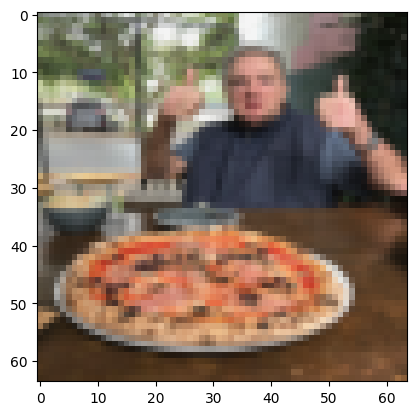

In [179]:
plt.imshow(custom_image_transformed.permute(1, 2, 0))

In [180]:
model_1.eval()
with torch.inference_mode():
  custom_image_pred = model_1(custom_image_transformed.unsqueeze(dim=0).to(device))

# doing unsqueeze to add the batch_data feature as in the trianing data

In [181]:
custom_image_pred

tensor([[ 0.0781,  0.0379, -0.2067]])

In [182]:
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

when predicting on custom data:
1. shape mismatch
2. device mismatch
3. datatype mismatch

In [183]:
# convert logits to prediction
custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
custom_image_pred_probs

tensor([[0.3686, 0.3541, 0.2773]])

In [184]:
custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1)
custom_image_pred_label

tensor([0])

In [187]:
class_names_found[custom_image_pred_label]

'pizza'

### 11.3 Putting custom image prediction together by combining all of them in a funciton

In [194]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str] = None,
                        transform = None,
                        device = device):
  # Load in the image
  target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

  # get the values in between 0 and 1
  target_image /= 255.

  # transform data if necessary
  if transform:
    target_image = transform(target_image)

  model.to(device)

  # predict using the model
  model.eval()
  with torch.inference_mode():
    target_image = target_image.unsqueeze(dim = 0)

    # make prediction
    target_image_pred = model(target_image.to(device))

  target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
  target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

  # plot image with prediction and prediction probability
  plt.imshow(target_image.squeeze().permute(1, 2, 0))
  if class_names:
    plt.title(f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max():.3f}")
  else:
    plt.title(f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max():.3f}")
  plt.axis(False);

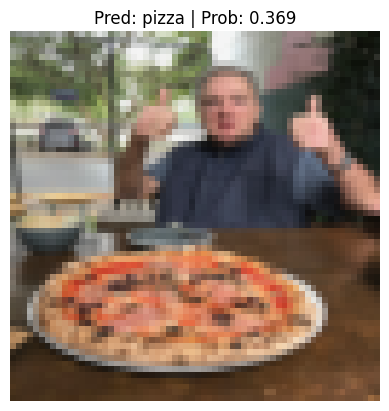

In [195]:
# pred on custom image
pred_and_plot_image(model = model_1,
                    image_path= custom_image_path,
                    class_names = class_names_found,
                    transform = custom_transform,
                    device = device)